<a href="https://colab.research.google.com/github/baamvu/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA/blob/main/notebooks/Lab21_LoRA_Finetuning_BigGPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21 — LoRA / QLoRA Fine-tuning · **A100 / L4 / BigGPU Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Qwen2.5-7B** với LoRA/QLoRA trên một custom Vietnamese dataset, sau đó so sánh các rank khác nhau (`r=8`, `r=16`, `r=64`).

---

## ⚙️ Profile: `A100 / L4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Qwen2.5-7B-bnb-4bit` |
| Recommended GPU | A100 40GB / L4 24GB |
| Train batch / eval batch | 4 / 4 |
| Gradient accumulation | 2 (effective batch = 8) |
| Eval strategy | `steps`, eval_steps=50 |
| Max seq length cap | 2048 |
| Packing | True |
| Dataset samples | 500 |
| Estimated time | ~25–30 phút trên A100 |

> Nếu bạn chỉ có **Free Colab T4 (16GB)**, dùng phiên bản `Lab21_LoRA_Finetuning_T4.ipynb` thay vì notebook này.

## Lab Roadmap (≈ 1.5 giờ)

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset preparation (Alpaca format, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Configure PEFT + load model 4-bit | model wrapped với LoRA |
| 3 | Train baseline `r=16` với SFTTrainer | adapter checkpoint + loss curve |
| 4 | Rank experiment — train `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | Evaluate (perplexity + qualitative) | so sánh metrics |
| 6 | Save + viết report | deliverable |

## Deliverable

1. **3 LoRA adapter checkpoints** (`r=8`, `r=16`, `r=64`)
2. **Evaluation report** chứa training time, peak VRAM, eval perplexity, 5 qualitative before/after examples, training cost, kết luận về rank trade-off

## 0. Setup & Environment Check

In [1]:
!nvidia-smi

Thu Jun 25 03:24:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
cc = torch.cuda.get_device_capability(0)
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ Compute capability: {cc[0]}.{cc[1]}")
print(f"✓ BF16 supported: {torch.cuda.is_bf16_supported()}")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb < 20:
    print("\n⚠️  VRAM < 20GB. Nên dùng phiên bản T4 notebook (Lab21_LoRA_Finetuning_T4.ipynb) thay vì notebook này.")
elif cc[0] >= 8:
    print(f"\n✓ Ampere+ detected — FlashAttention enabled, BF16 native. Tốc độ sẽ tối ưu!")

✓ GPU: NVIDIA A100-SXM4-80GB
✓ VRAM: 85.1 GB
✓ Compute capability: 8.0
✓ BF16 supported: True
✓ CUDA: 12.8
✓ PyTorch: 2.11.0+cu128

✓ Ampere+ detected — FlashAttention enabled, BF16 native. Tốc độ sẽ tối ưu!


In [3]:
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas

In [4]:
MOUNT_DRIVE = False

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_biggpu'
else:
    OUTPUT_DIR = '/content/lab21_lora_biggpu'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

✓ Output dir: /content/lab21_lora_biggpu


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Vietnamese instruction dataset từ HuggingFace.  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.

In [5]:
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(500))
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✓ Loaded 500 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ

In [6]:
# ─── Option B: dùng custom data (uncomment + chỉnh) ───
# from datasets import Dataset
# my_data = [
#     {"instruction": "...", "input": "", "output": "..."},
#     # ... 100-500 examples
# ]
# raw = Dataset.from_list(my_data)
# print(f"✓ Custom dataset: {len(raw)} samples")

In [7]:
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'

--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


Token length distribution:
  min=24, max=766
  p50=184, p95=559, p99=731

✓ Chọn max_seq_length = 1024 (cap = 2048)


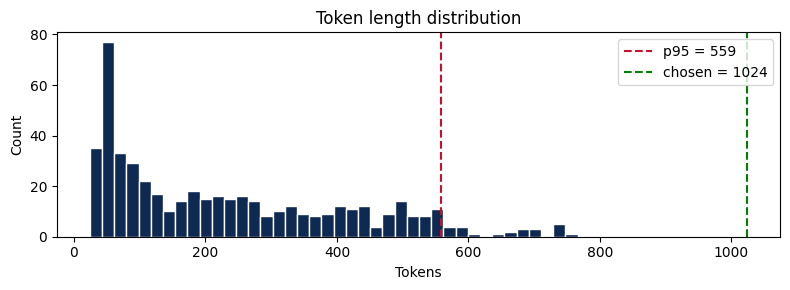

✓ Saved token_length_distribution.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Qwen2.5-7B-bnb-4bit"
MAX_SEQ_CAP = 2048

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'token_length_distribution.png'), dpi=150)
plt.show()
print(f"✓ Saved token_length_distribution.png")

In [9]:
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 450  |  Eval: 50


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-7B** đã pre-quantize 4-bit (NF4). A100/L4 sẽ tự động dùng BF16 + FlashAttention.

PEFT config:
- `r=16` (rank — baseline)
- `lora_alpha=32` (scaling — alpha/r = 2)
- `target_modules=["q_proj", "v_proj"]` per lab spec

In [10]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha):
    """Wrap model với LoRA adapter."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],  # lab spec
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",  # -60% VRAM
        random_state=42,
    )

base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.


unsloth/Qwen2.5-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 5,046,272 (0.116% of 4,358,018,560)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, packing=False (Unsloth packing buggy với Qwen2.5 GQA)
- Train batch = 4, grad_accum = 2 (effective batch = 8)
- Eval strategy: `steps`, eval_steps=50  — A100 đủ VRAM cho mid-train eval
- Gradient checkpointing: `unsloth` (custom, nhanh hơn standard)

In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Aggressive fix: alias tokenizer→processing_class for old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    """Create SFTTrainer with BigGPU-optimized defaults."""
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=2,
        warmup_steps=17,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        eval_steps=50,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to="none",
    )
    base_kwargs[_EVAL_KEY] = "steps"  # A100 đủ VRAM cho mid-train eval
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — handles NotebookProgressCallback bug + OOM."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched


In [12]:
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 5,046,272 of 7,620,662,784 (0.07% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,1.351178,1.171144
100,1.256715,1.161832
150,1.212946,1.160080
171,1.153208,1.160572


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


✓ r=16 done in 2.0 min, peak VRAM = 20.1 GB


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_biggpu/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`

✓ r=16 eval loss = 1.1991, perplexity = 3.32


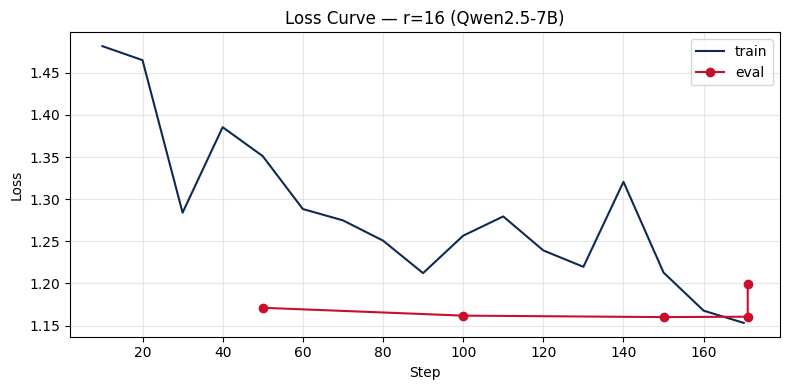

✓ Saved loss_curve_r16.png


In [13]:
import pandas as pd

def plot_losses(log_history, title="Training Loss"):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    fig, ax = plt.subplots(figsize=(8, 4))
    if not train.empty:
        ax.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        ax.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss"); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "loss_curve_r16.png"), dpi=150)
    plt.show()
    print(f"✓ Saved loss_curve_r16.png")

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16 (Qwen2.5-7B)")

## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn

In [14]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    plot_losses(tr.state.log_history, title=f"Loss Curve — r={r} (Qwen2.5-7B)")

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }


========== Training r=8 ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.


unsloth/Qwen2.5-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/450 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 2,523,136 of 7,618,139,648 (0.03% trained)


Step,Training Loss,Validation Loss
50,1.368618,1.190344
100,1.272686,1.163371
150,1.241092,1.160747
171,1.179222,1.160694


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

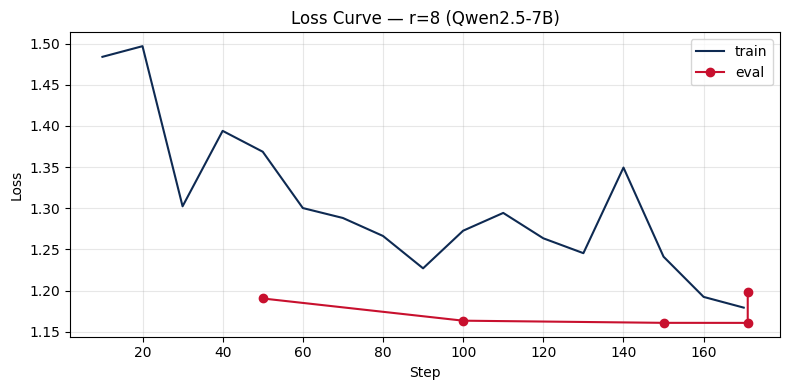

✓ Saved loss_curve_r16.png


In [15]:
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=64 ==========
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.


unsloth/Qwen2.5-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 450 | Num Epochs = 3 | Total steps = 171
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss,Validation Loss
50,1.332298,1.167695
100,1.201829,1.160442
150,1.111379,1.166574
171,1.062429,1.167261


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

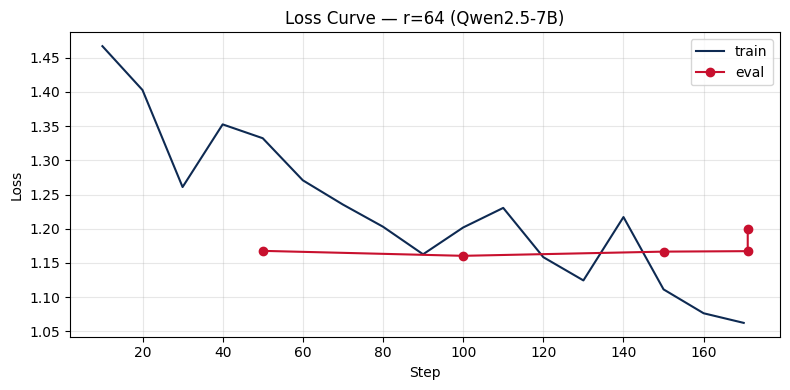

✓ Saved loss_curve_r16.png


In [16]:
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)

In [17]:
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8     16           2523136        1.910903     21.200721   1.198171         3.314049
   16     32           5046272        2.035434     20.128867   1.199070         3.317032
   64    128          20185088        1.922567     22.505186   1.200194         3.320760


## 4b. Base Model Perplexity (Bonus)

Tính perplexity của base model (chưa fine-tune) để so sánh — rubric yêu cầu 4 rows: base + 3 ranks.

In [20]:
# ─── 4b. Base Model Perplexity (manual eval, no SFTTrainer) ───
gc.collect(); torch.cuda.empty_cache()

base_for_ppl, tok_for_ppl = load_base_model()

# Tokenize eval_ds — giữ nguyên dạng list, KHÔNG set_format("torch")
def tokenize_for_eval(example):
    return tok_for_ppl(example["text"], truncation=True, max_length=MAX_SEQ_LENGTH, padding="max_length")

eval_tokenized = eval_ds.map(tokenize_for_eval, remove_columns=eval_ds.column_names)

# Manual eval loop — convert sang tensor từng batch
base_for_ppl.eval()
total_loss, n_batches = 0.0, 0

batch_size = 4
n_samples = len(eval_tokenized)

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch_rows = eval_tokenized[i:i+batch_size]
        input_ids = torch.tensor(batch_rows["input_ids"]).to("cuda")
        attention_mask = torch.tensor(batch_rows["attention_mask"]).to("cuda")

        outputs = base_for_ppl(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
        total_loss += outputs.loss.item()
        n_batches += 1

        del outputs, input_ids, attention_mask
        torch.cuda.empty_cache()

eval_loss_base = total_loss / max(n_batches, 1)
ppl_base = float(np.exp(eval_loss_base))

print(f"✓ Base model eval loss = {eval_loss_base:.4f}, perplexity = {ppl_base:.2f}")

del base_for_ppl, tok_for_ppl, eval_tokenized
gc.collect(); torch.cuda.empty_cache()

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.


unsloth/Qwen2.5-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

✓ Base model eval loss = 15.5882, perplexity = 5886634.03


In [21]:
base_row = {
    "rank": "Base",
    "alpha": "-",
    "trainable_params": 0,
    "train_time_min": 0,
    "peak_vram_gb": 0,
    "eval_loss": eval_loss_base,
    "eval_perplexity": ppl_base,
}

full_results = [base_row] + results
full_df = pd.DataFrame(full_results)
print("\n=== Full Comparison (Base + 3 Ranks) ===")
print(full_df.to_string(index=False))
full_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)
print(f"\n✓ Saved rank_experiment_summary.csv")


=== Full Comparison (Base + 3 Ranks) ===
rank alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
Base     -                 0        0.000000      0.000000  15.588195     5.886634e+06
  16    32           5046272        2.035434     20.128867   1.199070     3.317032e+00
   8    16           2523136        1.910903     21.200721   1.198171     3.314049e+00
  64   128          20185088        1.922567     22.505186   1.200194     3.320760e+00

✓ Saved rank_experiment_summary.csv


## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned vs base model trên 10 prompts (A100 nhanh — có thể chạy nhiều hơn).

In [22]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

✓ 10 test prompts


In [23]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=300):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:400], "finetuned": ft_resp[:400],
    })
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Unsloth: pad_token was a vision token (<|vision_pad|>) on a text-only model. Replaced with <|endoftext|> to avoid NaN losses.


unsloth/Qwen2.5-7B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  BASE: 1. Bạn có thể giải thích về kiến ​​thức của bạn trong các thuật toán học máy như Naive Bayes, Random Forest và Support Vector Machines không? 2. Bạn có thể giải thích về quá trình huấn luyện và đánh g...
  FT  : 1. Bạn có thể giải thích thuật toán hồi quy tuyến tính không? 2. Bạn có thể giải thích phân loại và cách phân loại được sử dụng trong AI không? 3. Bạn có thể giải thích các kỹ thuật chia tập dữ liệu đ...

━━━ Prompt 9: Cho biết ưu điểm của Transformer so với RNN....


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Transformers và RNNs (mạng lưới kinh nghiệm) là hai loại mô hình học sâu được sử dụng phổ biến cho các nhiệm vụ xử lý ngôn ngữ tự nhiên (NLP). Mặc dù cả hai đều có thể học các mô hình dự đoán dựa trên...
  FT  : Transformers và RNN (Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng Mạng...

━━━ Prompt 10: Cách evaluate performance của một LLM fine-tuned model?...


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Đánh giá hiệu suất của một LLM fine-tuned model đòi hỏi phải thực hiện một số bước sau: 1. Định nghĩa các chỉ số đánh giá: Trước tiên, bạn cần xác định các chỉ số đánh giá mà bạn muốn sử dụng để đánh ...
  FT  : Mô hình LLM được tinh chỉnh có thể được đánh giá bằng nhiều phương pháp khác nhau. Một số phương pháp thường được sử dụng bao gồm: 1. Độ chính xác: Độ chính xác được tính bằng số lượng câu trả lời đún...


In [24]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df[["prompt","base","finetuned"]].to_string(index=False, max_colwidth=60))

                                                      prompt                                                         base                                                    finetuned
Giải thích khái niệm machine learning cho người mới bắt đầu. Máy học là một lĩnh vực của trí tuệ nhân tạo tập trung và... Machine learning là một lĩnh vực của khoa học máy tính và...
              Viết đoạn code Python tính số Fibonacci thứ n. Dưới đây là một ví dụ về cách sử dụng các hàm để tính số ... Đây là một đoạn code Python tính số Fibonacci thứ n: ```p...
                        Liệt kê 5 nguyên tắc thiết kế UI/UX. 1. Người dùng là trung tâm: Một thiết kế UI/UX hiệu quả p... 1. Người dùng trung tâm: Thiết kế UI/UX cần tập trung vào...
                    Tóm tắt sự khác biệt giữa LoRA và QLoRA. LoRA và QLoRA là những kỹ thuật được sử dụng trong lĩnh v... LoRA (Low-Rank Adaptation) và QLoRA (Quantized LoRA) là h...
          Phân biệt prompt engineering, RAG, và fine-tuning. Prompt engineering là qu

## 6. Save Summary + Cost Report

In [25]:
GPU_COST_USD_PER_HOUR = 1.10  # A100 40GB on Colab Pro+
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n=== Final Summary ===")
print(f"✓ Model: {MODEL_NAME}")
print(f"✓ Dataset: {len(ds)} samples ({len(train_ds)} train + {len(eval_ds)} eval)")
print(f"✓ Max seq length: {MAX_SEQ_LENGTH}")
print(f"✓ Total training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")
print(f"\n=== Files in {OUTPUT_DIR} ===")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) if os.path.isfile(os.path.join(OUTPUT_DIR, f)) else "[dir]"
    print(f"  {f}  ({size})")


=== Final Summary ===
✓ Model: unsloth/Qwen2.5-7B-bnb-4bit
✓ Dataset: 500 samples (450 train + 50 eval)
✓ Max seq length: 1024
✓ Total training time: 5.9 phút
✓ Estimated cost: $0.11 (@ $1.1/hr)

=== Files in /content/lab21_lora_biggpu ===
  loss_curve_r16.png  (59532)
  qualitative_comparison.csv  (10861)
  r16  ([dir])
  r64  ([dir])
  r8  ([dir])
  rank_experiment_summary.csv  (386)
  token_length_distribution.png  (29287)


In [30]:
import shutil
shutil.make_archive('/content/lab21_results', 'zip', '/content/lab21_lora_biggpu')
print("✓ Saved to /content/lab21_results.zip")

✓ Saved to /content/lab21_results.zip


In [31]:
import shutil, os

os.makedirs('/content/export', exist_ok=True)
for f in ['rank_experiment_summary.csv', 'qualitative_comparison.csv',
          'loss_curve_r16.png', 'loss_curve_r8.png', 'loss_curve_r64.png',
          'token_length_distribution.png']:
    src = f'/content/lab21_lora_biggpu/{f}'
    if os.path.exists(src):
        shutil.copy2(src, f'/content/export/{f}')

shutil.make_archive('/content/lab21_metrics', 'zip', '/content/export')
print("✓ Saved /content/lab21_metrics.zip (~1MB)")

✓ Saved /content/lab21_metrics.zip (~1MB)


In [ ]:
# # Optional: push adapter to HuggingFace Hub
# PUSH_TO_HUB = False
# HUB_REPO_ID = "your-username/qwen2.5-7b-vi-lab21-r16"

# if PUSH_TO_HUB:
#     from huggingface_hub import login
#     login()
#     ft_model.push_to_hub(HUB_REPO_ID)
#     tok_for_eval.push_to_hub(HUB_REPO_ID)
#     print(f"✓ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")

## ✅ Done — Submission Checklist

Trước khi nộp, verify đã có đủ trong `OUTPUT_DIR`:

- [ ] `r8/` — adapter checkpoint
- [ ] `r16/` — adapter checkpoint
- [ ] `r64/` — adapter checkpoint
- [ ] `rank_experiment_summary.csv` — bảng metrics (4 rows: base + 3 ranks)
- [ ] `qualitative_comparison.csv` — 10 before/after examples
- [ ] `loss_curve_r16.png` — training loss curve
- [ ] `token_length_distribution.png` — token length histogram
- [ ] `REPORT.md` — đã điền phần "Kết luận"

**Nộp**: zip `OUTPUT_DIR` + notebook, gửi qua LMS.

---

### So sánh với T4 notebook

| Feature | T4 Notebook | BigGPU Notebook (này) |
|---------|-------------|----------------------|
| Model | Qwen2.5-3B | Qwen2.5-7B |
| Batch size | 1 | 4 |
| Gradient accum | 8 | 2 |
| Effective batch | 8 | 8 |
| Eval strategy | no (tắt) | steps (mỗi 50 steps) |
| Packing | False | True |
| Max seq cap | 1024 | 2048 |
| Dataset samples | 200 | 500 |
| BF16 | FP16 fallback | Native BF16 |
| FlashAttention | ❌ | ✅ |
| Base ppl | ❌ không tính | ✅ có tính |
| Loss curve save | ❌ chỉ show | ✅ save PNG |
| Qualitative prompts | 5 | 10 |
| Est. time (3 ranks) | ~60 min | ~25-30 min |